### Context

Education is fast becoming a very competitive sector with hundreds of institutions to choose from. It is a life-transforming experience for any student and it has to be a thoughtful decision. There are ranking agencies that do a survey of all the colleges to provide more insights to students. Agency RankForYou wants to leverage this year's survey to roll out an editorial article in leading newspapers, on the state of engineering education in the country. Head of PR (Public Relations) comes to you, the data scientist working at RankForYou, and asks you to come up with evidence-based insights for that article.

### Objective

As a data scientist working at RankForYou, you have been asked to identify the different types of engineering colleges in the country to better understand the state of affairs. The key questions that need to be answered are:
- How many different types (clusters/segments) of colleges can be found from the data?
- How do these different groups of colleges differ from each other?
- Do you get slightly different solutions from two different techniques? How would you explain the difference?


### Data Description

The data contains survey results for 26 engineering colleges. The initial survey data has been summarized into a rating scale of 1-5 for different factors.

**Factor rating index**
 - 1 - Very low
 - 2 - Low
 - 3 - Medium
 - 4 - High
 - 5 - Very high
 
**Data Dictionary**
 - SR_NO: Serial Number
 - Engg_College: 26 Engineering colleges with pseudonyms A to Z
 - Teaching: Quality of teaching at the engineering college
 - Fees: Fees at the engineering college
 - Placements: Job placements after a student graduates from the engineering college
 - Internship: Student Internships at the engineering college
 - Infrastructure: Infrastructure of the engineering college

In [1]:
import warnings
warnings.filterwarnings("ignore")
import string

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as  sns

from sklearn.preprocessing import StandardScaler

from scipy.spatial.distance import cdist

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

## Reading the Data

In [2]:
data = pd.read_excel('Engineering_Colleges_Case_Study.xlsx')
data.head()

,SR_NO,Engg_College,Teaching,Fees,Placements,Internship,Infrastructure
0,1,A,5,2,5,5,3
1,2,B,4,2,5,5,3
2,3,C,4,5,5,4,5
3,4,D,5,4,5,4,4
4,5,E,2,5,2,2,5


In [3]:
data.tail()

,SR_NO,Engg_College,Teaching,Fees,Placements,Internship,Infrastructure
21,22,V,2,2,1,2,1
22,23,W,2,5,1,1,1
23,24,X,1,1,1,2,5
24,25,Y,1,1,1,1,5
25,26,Z,3,4,5,2,3


In [4]:
data.sample(n=10, random_state=1)

,SR_NO,Engg_College,Teaching,Fees,Placements,Internship,Infrastructure
18,19,S,3,5,4,3,3
13,14,N,3,5,3,3,4
17,18,R,3,4,4,3,3
3,4,D,5,4,5,4,4
22,23,W,2,5,1,1,1
10,11,K,3,4,3,4,5
19,20,T,3,5,3,2,3
20,21,U,2,2,2,2,1
4,5,E,2,5,2,2,5
2,3,C,4,5,5,4,5


In [5]:
data.shape

(26, 7)

### Checking the data types of the columns for the dataset

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   SR_NO           26 non-null     int64 
 1   Engg_College    26 non-null     object
 2   Teaching        26 non-null     int64 
 3   Fees            26 non-null     int64 
 4   Placements      26 non-null     int64 
 5   Internship      26 non-null     int64 
 6   Infrastructure  26 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 1.6+ KB


### Statistical summary of the dataset

In [7]:
data.describe()

,SR_NO,Teaching,Fees,Placements,Internship,Infrastructure
count,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000
mean,13.500000,2.807692,3.576923,2.884615,2.769231,3.384615
std,7.648529,1.132051,1.331858,1.531716,1.242826,1.298520
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,7.250000,2.000000,2.250000,1.250000,2.000000,3.000000
50%,13.500000,3.000000,4.000000,3.000000,2.000000,3.000000
75%,19.750000,3.000000,5.000000,4.000000,4.000000,4.750000
max,26.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [8]:
# Checking for missing values
data.isna().sum()

SR_NO             0
Engg_College      0
Teaching          0
Fees              0
Placements        0
Internship        0
Infrastructure    0
dtype: int64

### Create copy of original dataset

In [9]:
df = data.copy()

In [10]:
# Drop serial number as it is not needed
df.drop(["SR_NO"], axis=1, inplace=True)

In [11]:
df.columns

Index(['Engg_College', 'Teaching', 'Fees', 'Placements', 'Internship',
       'Infrastructure'],
      dtype='object')

In [12]:
df.Teaching.nunique()

5

In [13]:
df.Teaching.unique()

array([5, 4, 2, 3, 1], dtype=int64)

## Exploratory Data Analysis

### Univariate Analysis

In [14]:
# Define function to create a histogram and box plot for an attribute
def hist_box_plots(df, col):
    """
    Create a histogram and bookplot of the column and dataframe provided
    
    df: dataframe
    col: dataframe column
    """
    
    # Create the plot figure
    plt.figure(figsize=(12,3))
    
    ################################################
    
    # Creating first subplot
    plt.subplot(1,2,1) 
    
    # Add title and labels
    plt.title(string.capwords(col.replace('_',' ')), fontsize=12, pad=20, loc='left')        
    plt.xlabel(string.capwords(col.replace('_',' ')), fontsize=10, labelpad=5)
    plt.ylabel('Record Count', fontsize=10, labelpad=10)
    
    # Set tick font sizes
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    
    # Create a histogram of the attribute
    ax = sns.histplot(data = df, x=col, color='#CCECFF')
    
    # Hide the top and left spines of the histogram
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add a mean to the histogram
    ax.axvline(df[col].mean(), color='green', linestyle='--')
    
    # Add median to the histogram
    ax.axvline(df[col].median(), color='red', linestyle='-')
        
    ################################################    
    
    # Create second box plot next to first boxplot
    plt.subplot(1,2,2)
                
    # Set the flier type, color, and size of the outliers            
    flierprops = dict(marker='o', markerfacecolor='Red', markersize='9')
                
    # Add an x-axis label            
    plt.xlabel(string.capwords(col.replace('_',' ')), fontsize=10, labelpad=5,)
                
    # Set the tick font size            
    plt.xticks(fontsize=10)
                
    # Create a boxplot of the attribute            
    ax = sns.boxplot(data = df, x=col, showmeans=True, flierprops=flierprops, color='#CCECFF')
                
    # Hide the top, right, and left spines            
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Show the plot
    plt.show()
    
    # Print and line after the graphs to delineate between multiple calls
    print('_'*122)


In [15]:
num_cols = df.select_dtypes(include=np.number).columns

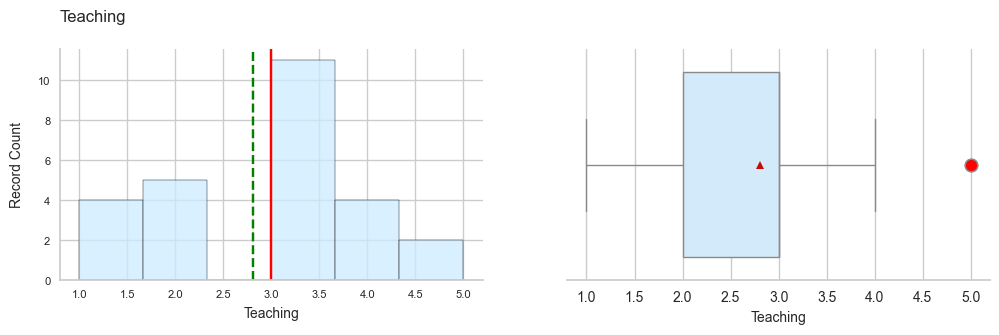

__________________________________________________________________________________________________________________________


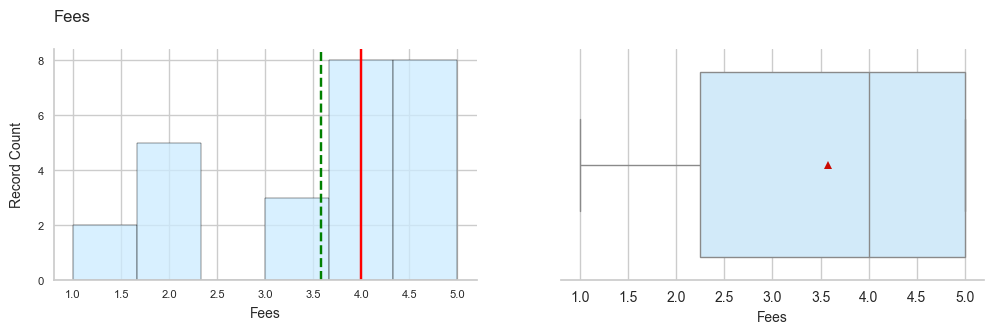

__________________________________________________________________________________________________________________________


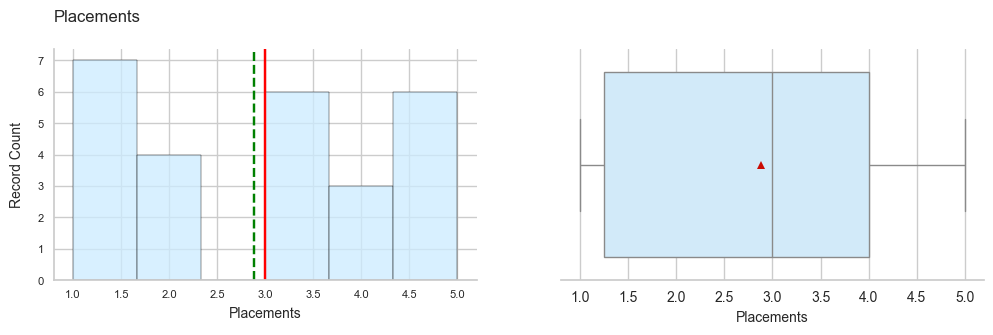

__________________________________________________________________________________________________________________________


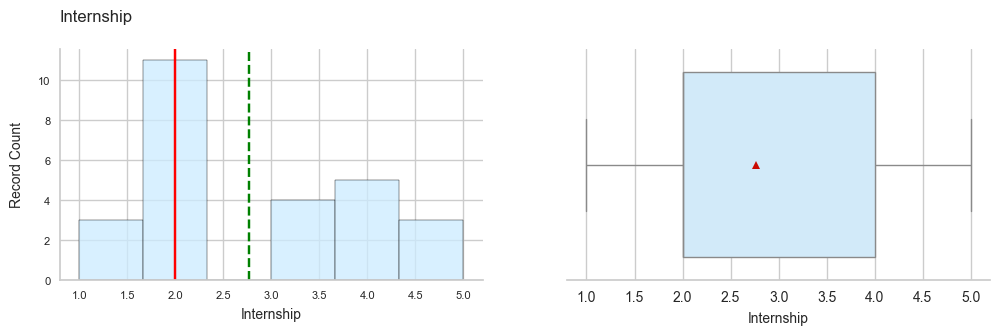

__________________________________________________________________________________________________________________________


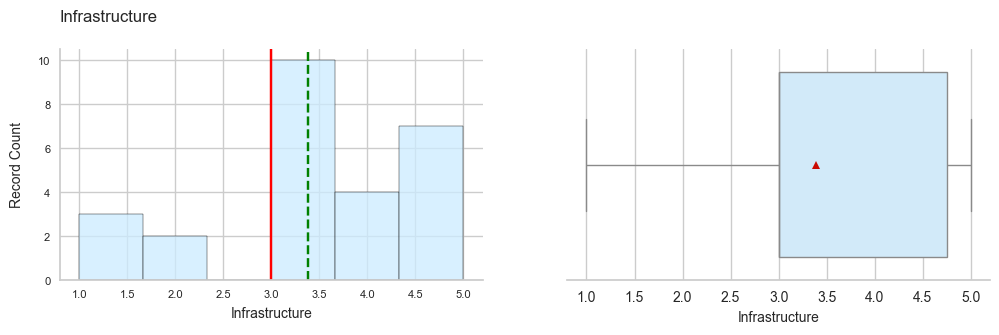

__________________________________________________________________________________________________________________________


In [16]:
for col in num_cols:
    hist_box_plots(df, col)

In [17]:
# Define function to create a bar plot for category attributes
# Includes options for % or int column value and sorting columns
def bar_plot(data, col, perc=False, countorder = False):
    """
    Create a bar plot of the column and dataframe provided
    
    data: dataframe
    col: dataframe column
    perc: True will show % of total for each column, False will show record count
    countorder: True will order columns by column count, False will order columns by category name
    """
    
    # For each value in the list of categories, create a bar chart
    
    
    total = len(data[col])  # length of the column
    count = data[col].nunique()
    
    # If there are less than 8 unique values in the attribute, set the size to 4 by 3
    # else set the size to 9 by 3 to show all values cleaner
    if data[col].nunique() < 8:
        plt.figure(figsize=(8,3))
    else: 
        plt.figure(figsize=(9,3))
    
    if countorder == True:
        order = data[col].value_counts().index[:]
    else:
        order = data[col].sort_values()
    
    # Create the bar plot of the dataframe and all attributes individually
    # Order the each subplot by the x-axis data xtick names
    ax = sns.countplot(data=data,
                       x=col,
                       color='#CCECFF',
                       linewidth=.5, edgecolor='black',
                       order = order)
    
    # Add title and labels
    plt.title(string.capwords(col.replace('_',' ')), fontsize=12, pad=10, loc='left')
    plt.xlabel(string.capwords(col.replace('_',' ')), fontsize=10, labelpad=5,)
    plt.ylabel('Record Count', fontsize=10, labelpad=5)

    # If there is less than 20 unique values for the attribute, do not rotate the x-tick label
    # else rotate the x-tick label by 90 degrees for readability
    if data[col].nunique() < 20:
        plt.xticks(rotation=0, fontsize=8) 
    else:
        plt.xticks(rotation=90, fontsize=8)               
    plt.yticks(fontsize=8)
    
    
    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = int(p.get_height())  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot
    
        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=9,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage
    
    
    # Tighten the layout of the subplots
    plt.tight_layout()    
    
    # Hide the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Show the plot
    plt.show()
    
    # Print and line after the graphs to delineate between multiple calls
    print('_'*122)


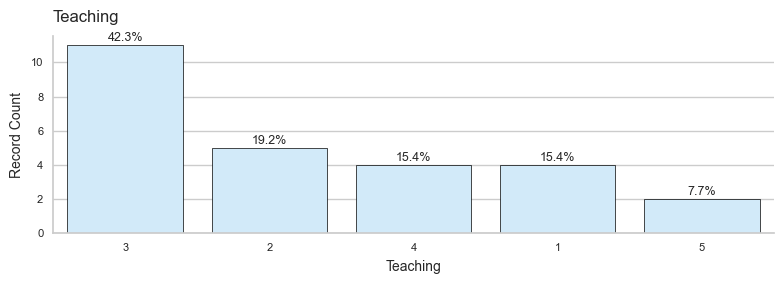

__________________________________________________________________________________________________________________________


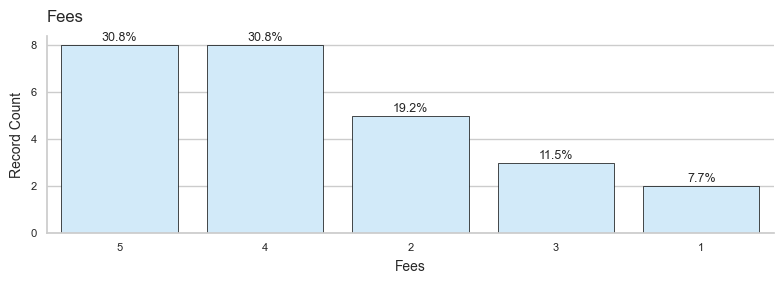

__________________________________________________________________________________________________________________________


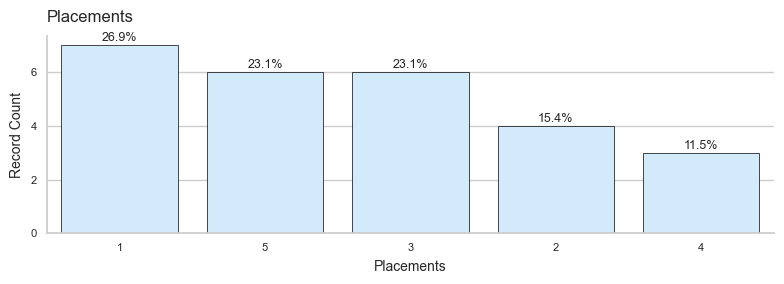

__________________________________________________________________________________________________________________________


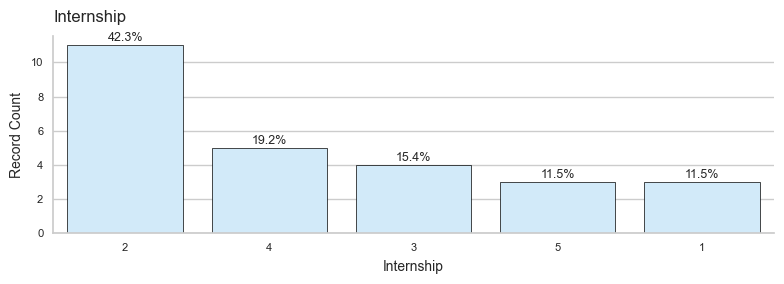

__________________________________________________________________________________________________________________________


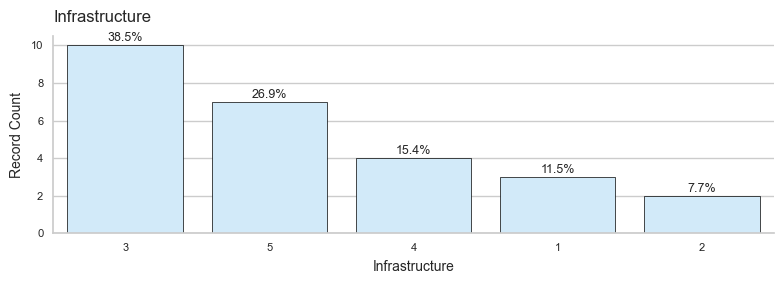

__________________________________________________________________________________________________________________________


In [18]:
for col in num_cols:
    bar_plot(df, col, perc=True, countorder=True)

### Bivariate Analysis

In [19]:
# Create a heatmap of the correlation of the numerical attributes
def create_heatmap(df):
    """
    Create heatmap of a dataframe's numerical columns
    df: name of dataframe
    """
    
    num_cols = df.select_dtypes(include=np.number).columns
    
    labels = []
    
    for col in num_cols:
        label=col.replace('_','').split()
        labels.append(''.join(x[:].capitalize() for x in label))

    plt.figure(figsize=(15,7))
    sns.heatmap(df[num_cols].corr(), 
                xticklabels = labels,
                yticklabels = labels,
                annot=True, 
                vmin=-1, 
                vmax=1, 
                fmt=".2f", 
                cmap='Blues')
    # Add title
    plt.title('Heatmap: Numerical Attributes')
    
    plt.show()

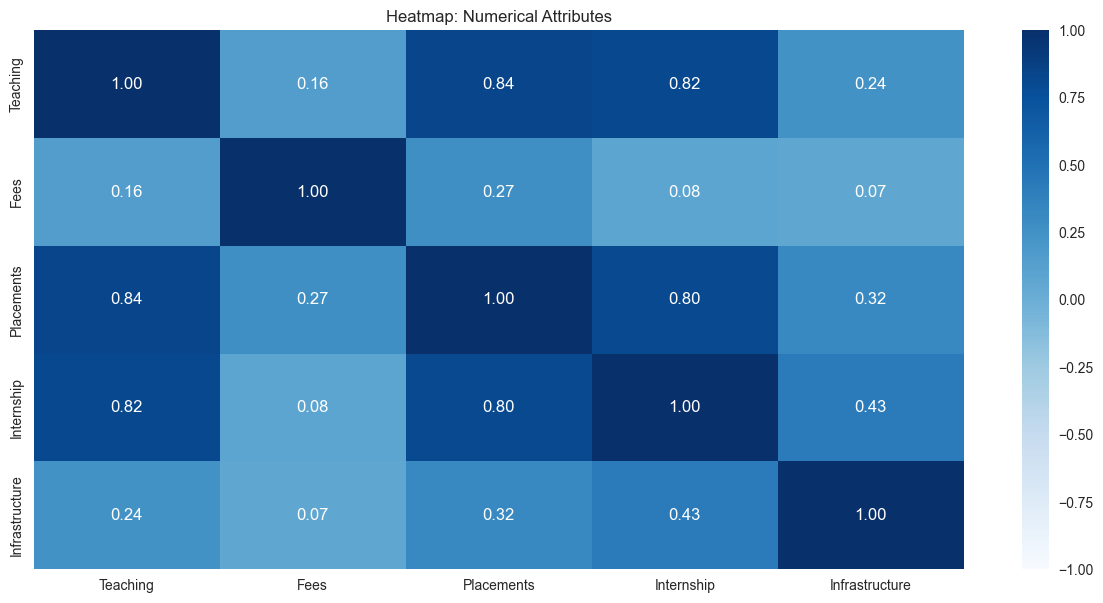

In [20]:
create_heatmap(df)

In [21]:
# Create a pairplot of the numerical attributes
def create_pairplot(df):
    """
    Create pairplot of a dataframe's numerical columns
    df: name of dataframe
    """
    
    num_cols = df.select_dtypes(include=np.number).columns
    tot_cols = num_cols.value_counts().sum()
    
    labels = []
    
    for col in num_cols:
        label=col.replace('_','').split()
        labels.append(''.join(x[:].capitalize() for x in label))

    ax = sns.pairplot(df[num_cols],
                      diag_kind='kde')
    
    # set xlabels
    for i in range(tot_cols):
            ax.axes[tot_cols-1,i].set_xlabel(labels[i])
                    
    # set ylabels
    for i in range(tot_cols):
            ax.axes[i,0].set_ylabel(labels[i])
            
    ax.fig.suptitle('Pairplot: Numerical Attributes', y=1.02);

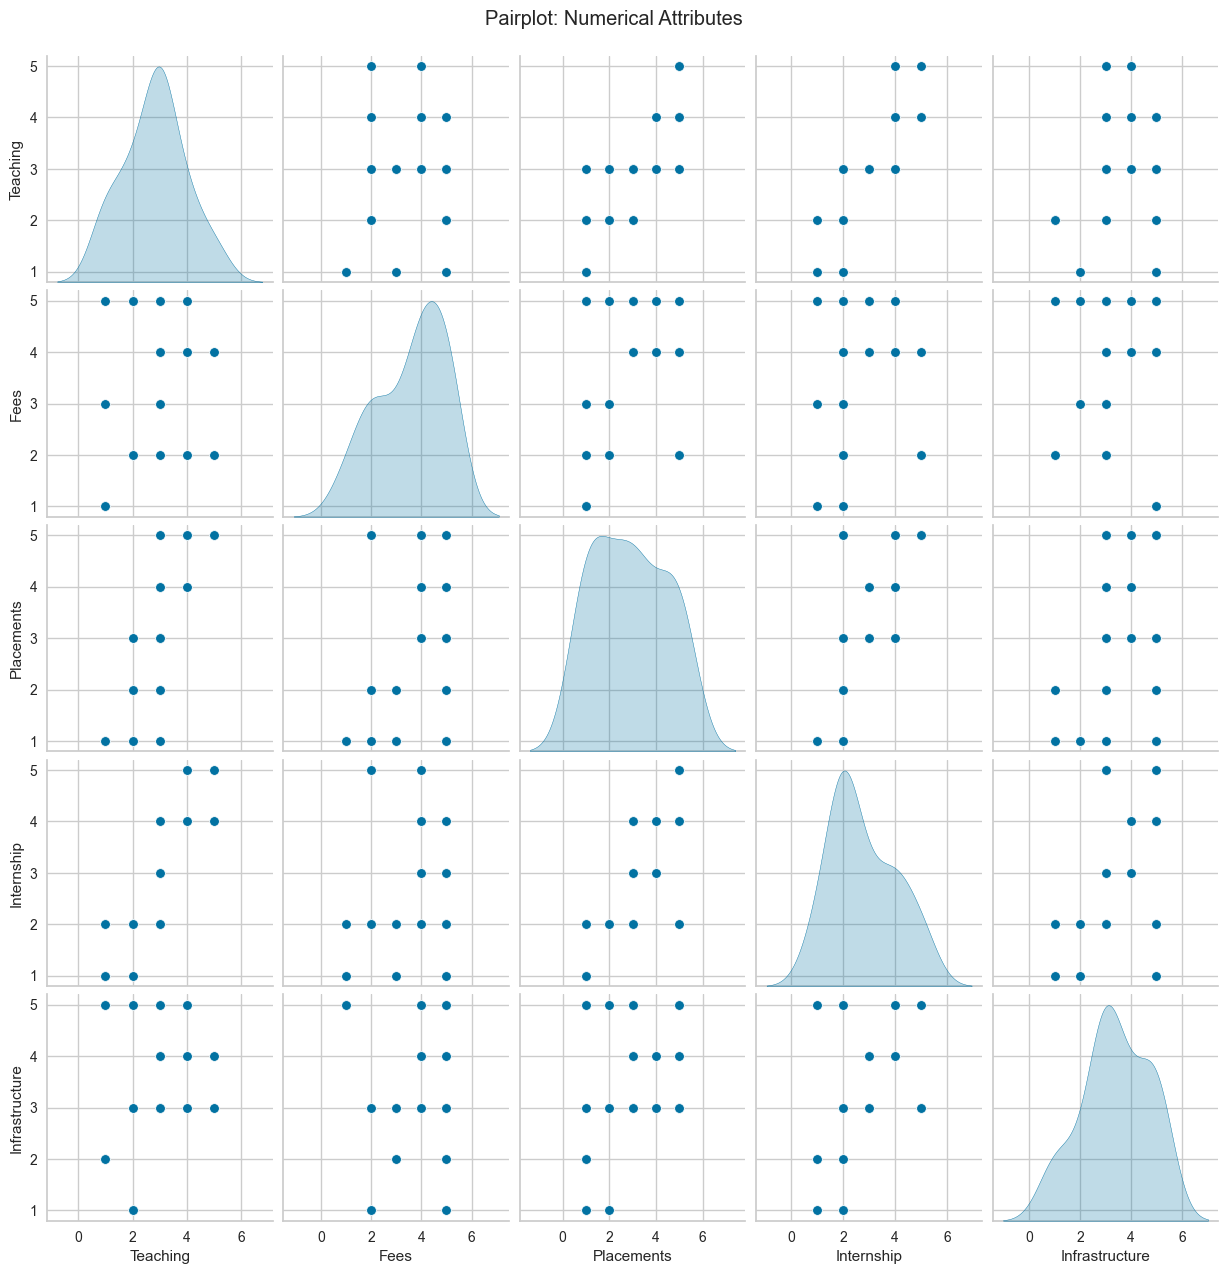

In [22]:
create_pairplot(df)

## Data Preprocessing

In [25]:
num_col = ['Teaching', 'Fees', 'Placements', 'Internship', 'Infrastructure'] 

# Scaling the data before clustering
scaler = StandardScaler()
subset = df[num_col].copy()
subset_scaled = scaler.fit_transform(subset)

In [26]:
# Create dataframe from the scaled data
subset_scaled_df = pd.DataFrame(subset_scaled,
                                columns=subset.columns)

## K-means Clustering

In [27]:
clusters = range(1,9)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k).fit(subset_scaled_df)
    prediction = model.predict(subset_scaled_df)
    distortion = (
        sum(np.min(cdist(subset_scaled_df,
                         model.cluster_centers_,
                         'euclidean'), axis=1)
           ) / subset_scaled_df.shape[0])
    meanDistortions.append(distortion)
    
    print("Number of Clusters:", k, "\tAverage Distortion", distortion)


Number of Clusters: 1 	Average Distortion 2.087990295998642
Number of Clusters: 2 	Average Distortion 1.6030760049686552
Number of Clusters: 3 	Average Distortion 1.3542868697697457
Number of Clusters: 4 	Average Distortion 1.1658645562214658
Number of Clusters: 5 	Average Distortion 1.085871475082126
Number of Clusters: 6 	Average Distortion 1.0010975753244238
Number of Clusters: 7 	Average Distortion 0.8046619356513329
Number of Clusters: 8 	Average Distortion 0.7072750736705818


Text(0.5, 1.0, 'Selecting K with the Elbow Method')

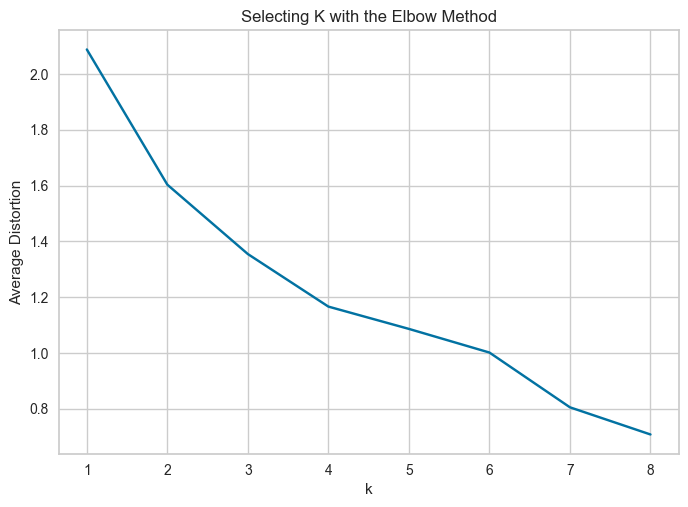

In [30]:
plt.plot(clusters, meanDistortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Average Distortion')
plt.title('Selecting K with the Elbow Method')

* The appropriate value of k from the elbow curve appears to be 4 or 5

### Silhouette scores

In [45]:
sil_score = []
cluster_list = list(range(2,10))
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters
        ).fit_predict((subset_scaled_df))
    score = silhouette_score(subset_scaled_df, clusterer)
    sil_score.append(score)
    print("For n_clusters = {}, silhouette score is {}".format(n_clusters, score))

For n_clusters = 2, silhouette score is 0.30806629823215215
For n_clusters = 3, silhouette score is 0.2896589939792401
For n_clusters = 4, silhouette score is 0.33463113210907935
For n_clusters = 5, silhouette score is 0.3578484211066675
For n_clusters = 6, silhouette score is 0.34349907930234863
For n_clusters = 7, silhouette score is 0.35308688708398334
For n_clusters = 8, silhouette score is 0.3589587694666124
For n_clusters = 9, silhouette score is 0.3877165782852194


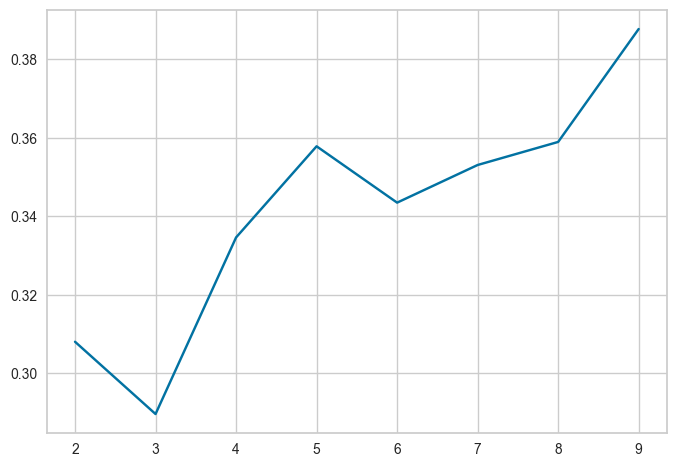

In [46]:
plt.plot(cluster_list, sil_score)

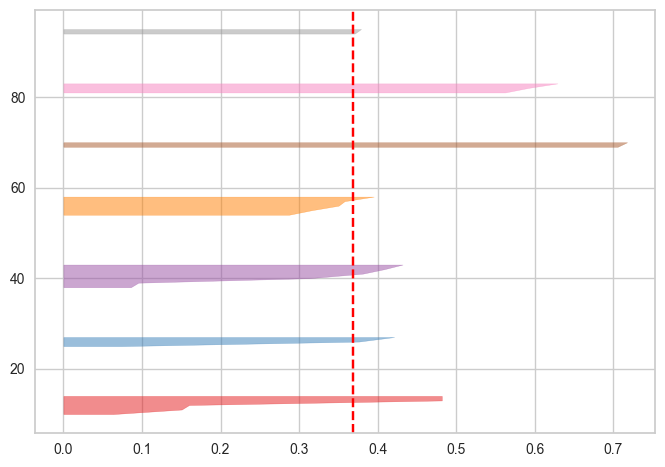

In [47]:
# finding the optimal number of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(7, random_state=1)).fit(subset_scaled_df)
plt.show()

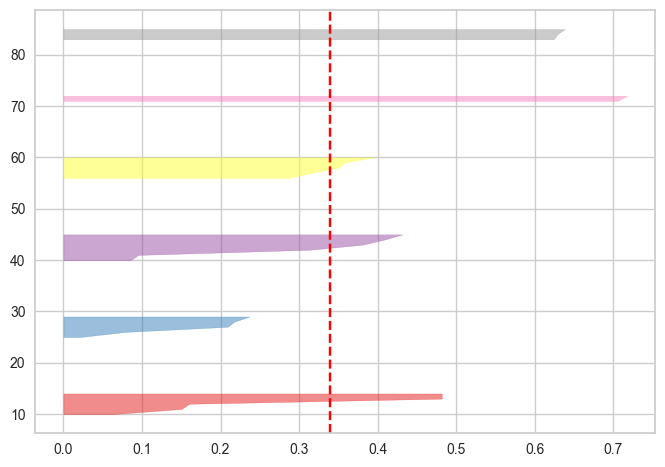

In [48]:
# finding the optimal number of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(6, random_state=1)).fit(subset_scaled_df)
plt.show()

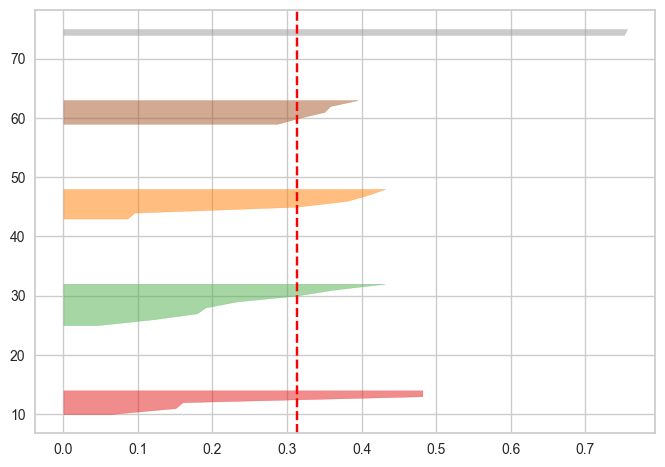

In [49]:
# finding the optimal number of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(5, random_state=1)).fit(subset_scaled_df)
plt.show()

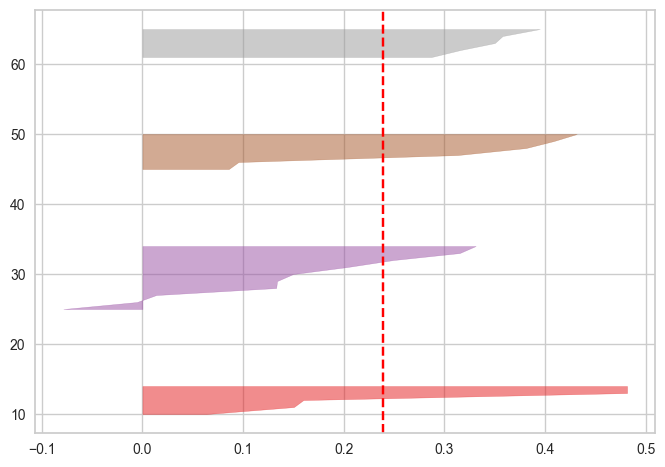

In [50]:
# finding the optimal number of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(4, random_state=1)).fit(subset_scaled_df)
plt.show()

### Selecting the final model

**Let's take 5 as the appropriate no. of clusters as the silhouette score is high enough and there is knick at 5 in the elbow curve.**

In [51]:
kmeans = KMeans(n_clusters=5, random_state=0)
kmeans.fit(subset_scaled_df)

KMeans(n_clusters=5, random_state=0)

In [52]:
# adding kmeans cluster labels to the origfinal dataframe
df["K_means_segments"] = kmeans.labels_

## Cluster Profiling

In [54]:
cluster_profile = df.groupby("K_means_segments").mean(numeric_only=True)

In [55]:
cluster_profile["count_in_each_segment"] = (
    df.groupby("K_means_segments")["Fees"].count().values
)

In [56]:
# let's display cluster profiles
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Teaching,Fees,Placements,Internship,Infrastructure,count_in_each_segment
K_means_segments,,,,,,
0,2.333333,2.500000,1.500000,1.833333,2.166667,6
1,3.000000,4.500000,3.666667,2.666667,3.333333,6
2,4.000000,3.625000,4.375000,4.375000,4.250000,8
3,1.750000,5.000000,1.750000,1.750000,2.750000,4
4,1.000000,1.000000,1.000000,1.500000,5.000000,2


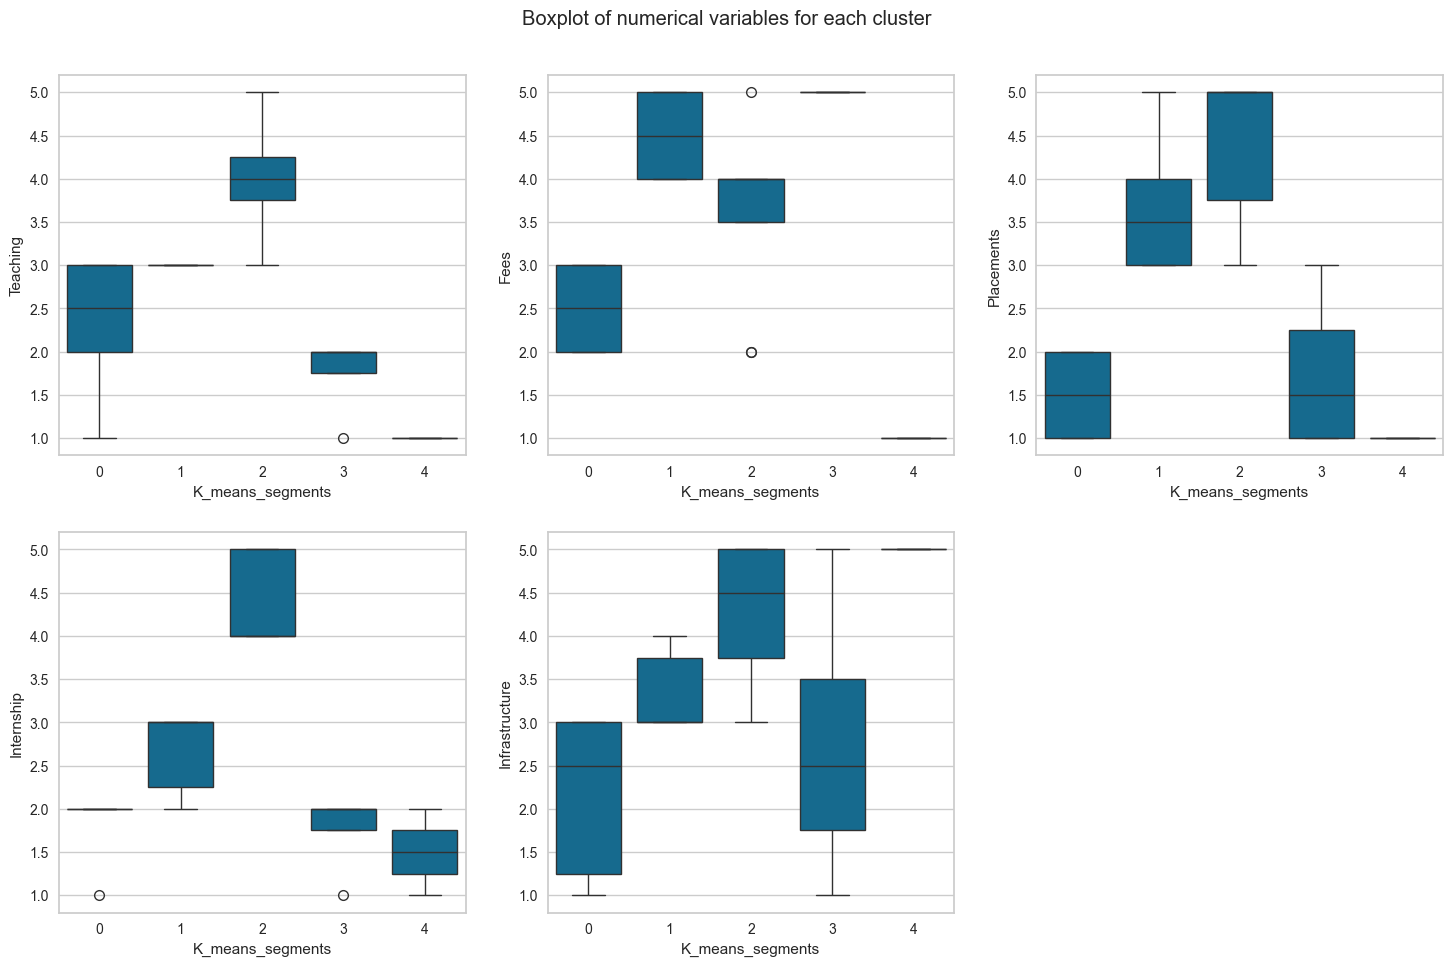

In [57]:
plt.figure(figsize=(15, 10))
plt.suptitle("Boxplot of numerical variables for each cluster")

for i, variable in enumerate(num_col):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(data=df, x="K_means_segments", y=variable)

plt.tight_layout(pad=2.0)

<Axes: xlabel='K_means_segments'>

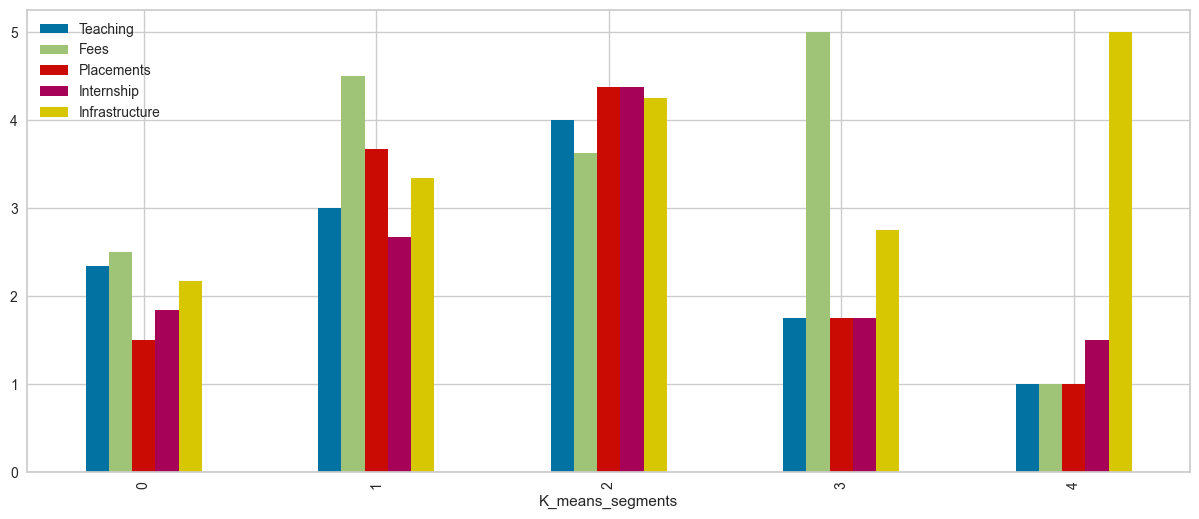

In [58]:
df.groupby("K_means_segments").mean(numeric_only=True).plot.bar(figsize=(15, 6))